# Week 4 — Part A: Time-Series Forecasting (ARIMA & Prophet)
**Career Launchpad Program — AI/DS Internship**
**Intern:** Ahmad | **Instructor:** Zaheer Ahmad — Lecturer, Computer Science

**Dataset:** Mauna Loa Atmospheric CO₂ concentration (weekly, 1958–2001), bundled with `statsmodels`
(`statsmodels.datasets.co2`). This is a genuine univariate time series with 2,284 raw weekly
observations spanning 43+ years — well above the 2-years / 500+ observation minimum — with a clear
long-term trend and strong yearly seasonality, making it ideal for comparing ARIMA and Prophet.

> **Note on dataset choice:** this sandbox environment only has outbound network access to a small
> allow-list of package/code-hosting domains (PyPI, GitHub, npm, etc.) and cannot reach general
> data sources such as Yahoo Finance or Kaggle. The `statsmodels` CO₂ dataset ships locally with the
> library, so it was chosen to keep this notebook fully self-contained and reproducible offline.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (11, 4)
np.random.seed(42)


Importing plotly failed. Interactive plots will not work.


## A.2 — Task 1 & 2: Load Data + Exploratory Data Analysis

In [2]:
# Load the Mauna Loa CO2 dataset (weekly observations)
raw = sm.datasets.co2.load_pandas().data
raw.index = pd.to_datetime(raw.index)

# Resample to monthly means (standard practice for this dataset - reduces missing-week gaps
# while retaining >500 observations and multi-year seasonality)
series = raw['co2'].resample('MS').mean()
series = series.interpolate(method='linear')  # fill any remaining gaps

print(f"Observations: {len(series)}")
print(f"Date range: {series.index.min().date()} to {series.index.max().date()}")
print(f"Span: {(series.index.max() - series.index.min()).days / 365.25:.1f} years")
series.describe()


Observations: 526
Date range: 1958-03-01 to 2001-12-01
Span: 43.8 years


count    526.000000
mean     339.619202
std       17.116453
min      313.400000
25%      324.025000
50%      337.912500
75%      354.537500
max      373.800000
Name: co2, dtype: float64

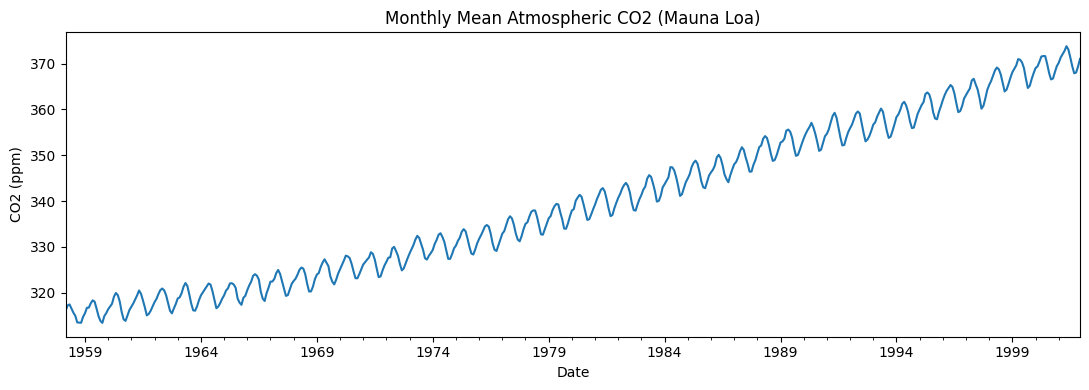

In [3]:
fig, ax = plt.subplots()
series.plot(ax=ax, title="Monthly Mean Atmospheric CO2 (Mauna Loa)")
ax.set_ylabel("CO2 (ppm)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.savefig("plots/A_raw_series.png", dpi=110)
plt.show()


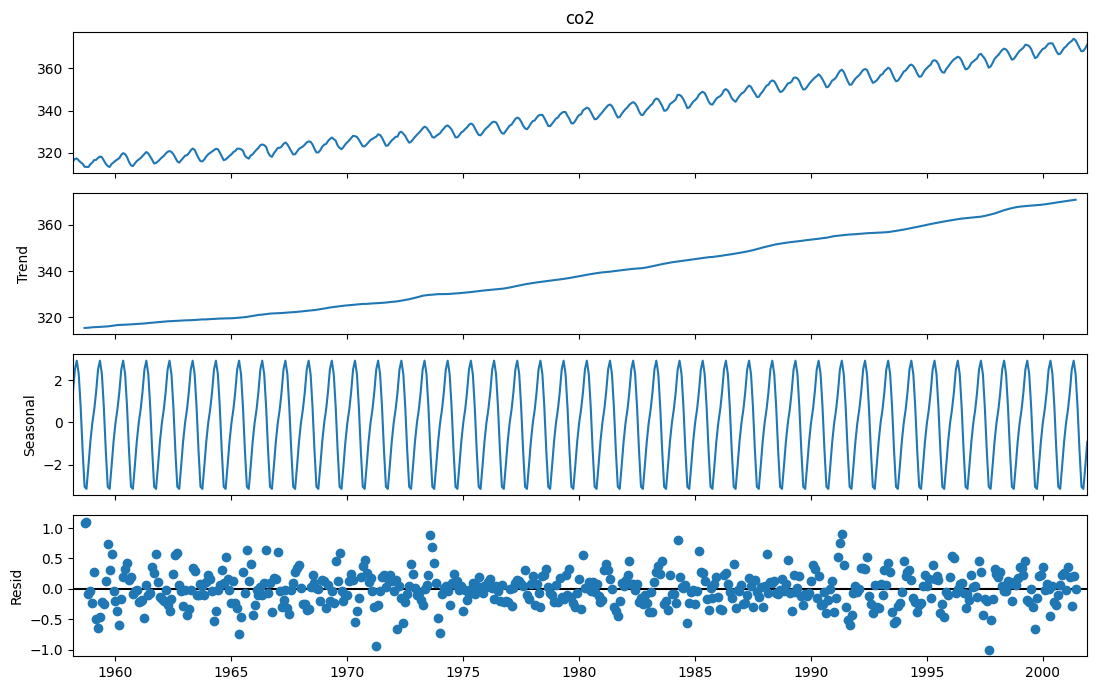

In [4]:
# Trend/seasonality decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(series, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig("plots/A_decomposition.png", dpi=110)
plt.show()


In [5]:
# Augmented Dickey-Fuller test for stationarity (on raw series)
result = adfuller(series.dropna())
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 6))
print("Critical Values:")
for k, v in result[4].items():
    print(f"   {k}: {round(v,4)}")

if result[1] < 0.05:
    print("\n=> Series is likely STATIONARY (reject H0)")
else:
    print("\n=> Series is likely NON-STATIONARY (fail to reject H0) - differencing required")


ADF Statistic: 2.2328
p-value: 0.998908
Critical Values:
   1%: -3.4432
   5%: -2.8672
   10%: -2.5698

=> Series is likely NON-STATIONARY (fail to reject H0) - differencing required


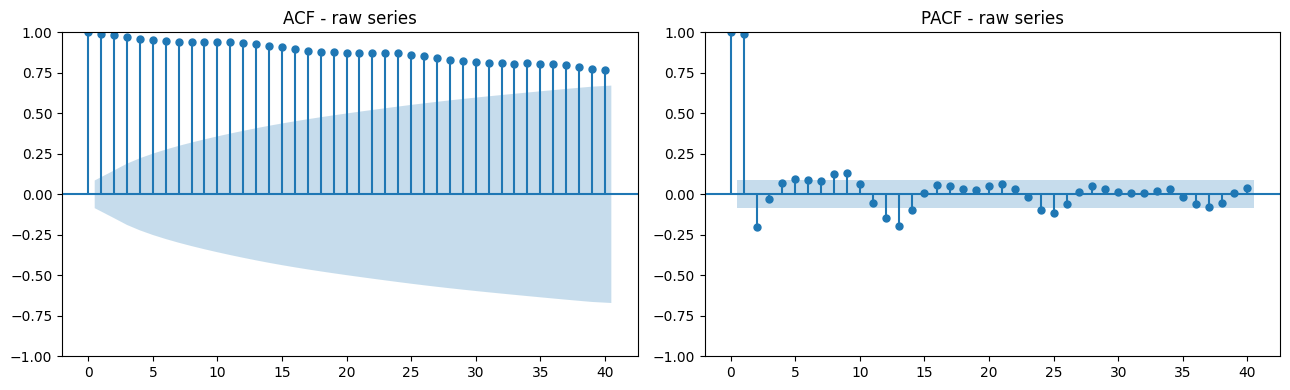

In [6]:
# ACF / PACF plots on the raw series
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series, lags=40, ax=axes[0])
plot_pacf(series, lags=40, ax=axes[1], method='ywm')
axes[0].set_title("ACF - raw series")
axes[1].set_title("PACF - raw series")
plt.tight_layout()
plt.savefig("plots/A_acf_pacf_raw.png", dpi=110)
plt.show()


## A.3 — Task 3: Differencing + ARIMA Model

In [7]:
# The ADF test above and the decomposition plot show a strong upward trend and yearly
# seasonality -> the series is non-stationary. Apply first-order differencing.
series_diff1 = series.diff().dropna()

result_diff = adfuller(series_diff1)
print("After 1st-order differencing:")
print("ADF Statistic:", round(result_diff[0], 4))
print("p-value:", round(result_diff[1], 6))
print("=> Stationary" if result_diff[1] < 0.05 else "=> Still non-stationary")


After 1st-order differencing:
ADF Statistic: -4.7519
p-value: 6.7e-05
=> Stationary


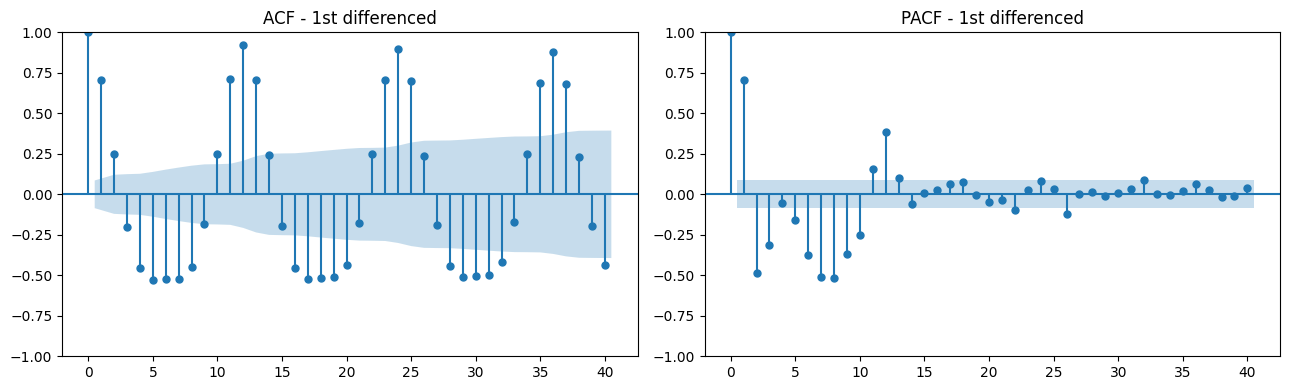

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(series_diff1, lags=40, ax=axes[0])
plot_pacf(series_diff1, lags=40, ax=axes[1], method='ywm')
axes[0].set_title("ACF - 1st differenced")
axes[1].set_title("PACF - 1st differenced")
plt.tight_layout()
plt.savefig("plots/A_acf_pacf_diff.png", dpi=110)
plt.show()


In [9]:
# Train / test split - last 20% as test set
n = len(series)
split = int(n * 0.8)
train, test = series.iloc[:split], series.iloc[split:]
print(f"Train: {len(train)} obs ({train.index.min().date()} - {train.index.max().date()})")
print(f"Test:  {len(test)} obs ({test.index.min().date()} - {test.index.max().date()})")


Train: 420 obs (1958-03-01 - 1993-02-01)
Test:  106 obs (1993-03-01 - 2001-12-01)


In [10]:
# Use auto_arima to select (p,d,q) by minimizing AIC (also search seasonal (P,D,Q,m))
auto_model = pm.auto_arima(
    train,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=None,                     # let auto_arima determine differencing via ADF/KPSS
    seasonal=True, m=12,
    start_P=0, max_P=2, start_Q=0, max_Q=2, D=None, max_D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1320.801, Time=0.02 sec


 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=879.616, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1321.759, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1082.271, Time=0.03 sec


 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=281.204, Time=0.34 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=445.168, Time=0.18 sec


 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=541.876, Time=0.54 sec


 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=300.590, Time=1.21 sec


...

 ARIMA(1,1,2)(1,0,1)[12]             : AIC=268.324, Time=0.71 sec


 ARIMA(0,1,0)(1,0,1)[12]             : AIC=inf, Time=0.22 sec


 ARIMA(0,1,2)(1,0,1)[12]             : AIC=272.153, Time=0.35 sec


 ARIMA(2,1,0)(1,0,1)[12]             : AIC=279.729, Time=0.46 sec


 ARIMA(2,1,2)(1,0,1)[12]             : AIC=270.712, Time=0.62 sec

Best model:  ARIMA(1,1,1)(1,0,1)[12]          
Total fit time: 29.260 seconds
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  420
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -128.661
Date:                            Mon, 07 Sep 2026   AIC                            267.322
Time:                                    14:02:32   BIC                            287.512
Sample:                                03-01-1958   HQIC                           275.303
                                     - 02-01-1993                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

In [11]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order
print("Selected order:", order, "seasonal_order:", seasonal_order)

# Refit with statsmodels SARIMAX for confidence intervals + easy forecasting API
sarimax_model = sm.tsa.statespace.SARIMAX(
    train, order=order, seasonal_order=seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

print(f"AIC: {sarimax_model.aic:.2f}   BIC: {sarimax_model.bic:.2f}")


Selected order: (1, 1, 1) seasonal_order: (1, 0, 1, 12)


AIC: 203.21   BIC: 223.23


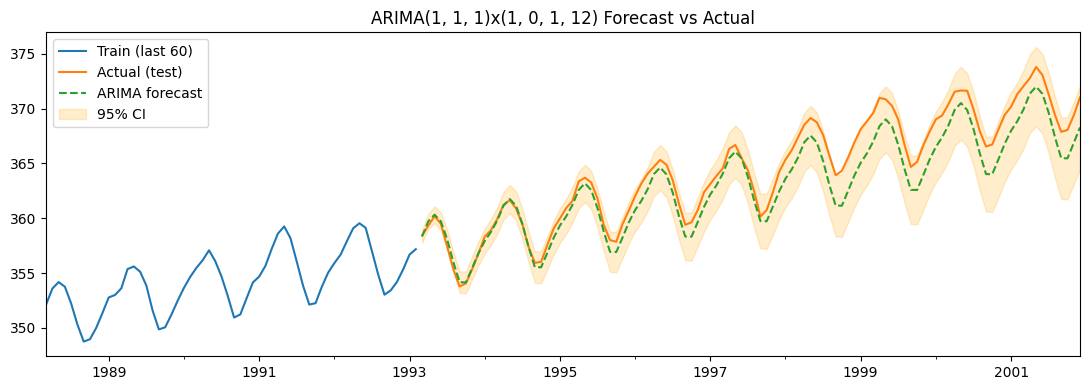

In [12]:
# Forecast over the test horizon with 95% confidence intervals
fc = sarimax_model.get_forecast(steps=len(test))
arima_pred = fc.predicted_mean
arima_ci = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots()
train.iloc[-60:].plot(ax=ax, label="Train (last 60)")
test.plot(ax=ax, label="Actual (test)")
arima_pred.plot(ax=ax, label="ARIMA forecast", style="--")
ax.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
                color='orange', alpha=0.2, label="95% CI")
ax.set_title(f"ARIMA{order}x{seasonal_order} Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.savefig("plots/A_arima_forecast.png", dpi=110)
plt.show()


## A.4 — Task 5: Prophet Model

In [13]:
prophet_df = series.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_train = prophet_df.iloc[:split]
prophet_test = prophet_df.iloc[split:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.95
)
prophet_model.fit(prophet_train)


14:02:33 - cmdstanpy - INFO - Chain [1] start processing


14:02:33 - cmdstanpy - INFO - Chain [1] done processing


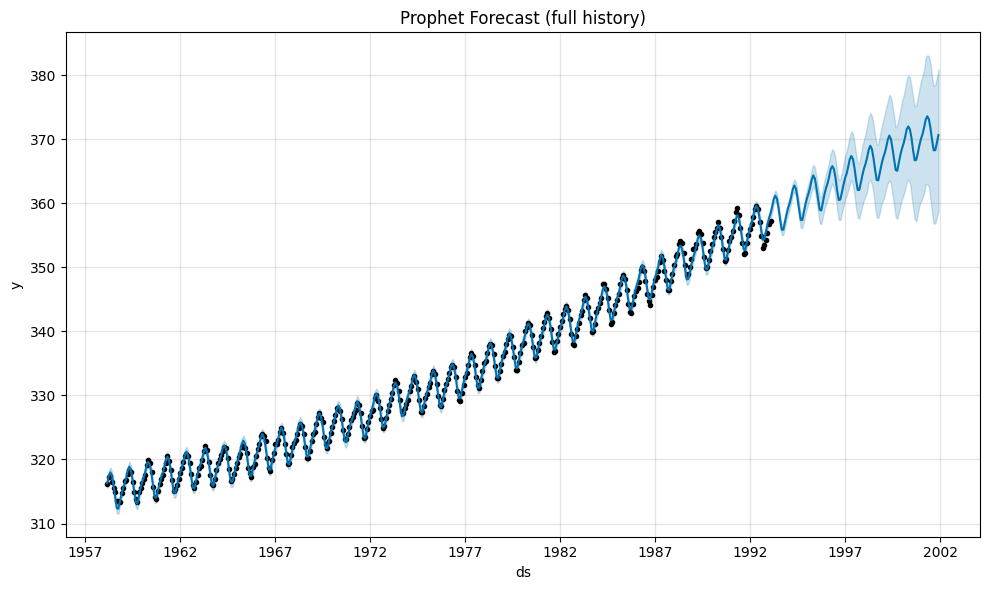

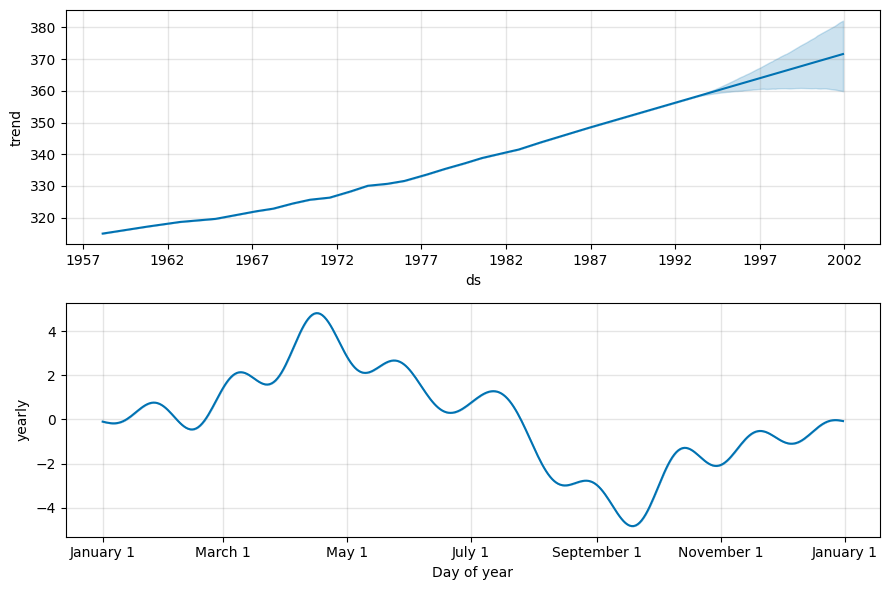

In [14]:
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')
prophet_forecast = prophet_model.predict(future)

fig1 = prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast (full history)")
plt.tight_layout()
plt.savefig("plots/A_prophet_full_forecast.png", dpi=110)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig("plots/A_prophet_components.png", dpi=110)
plt.show()


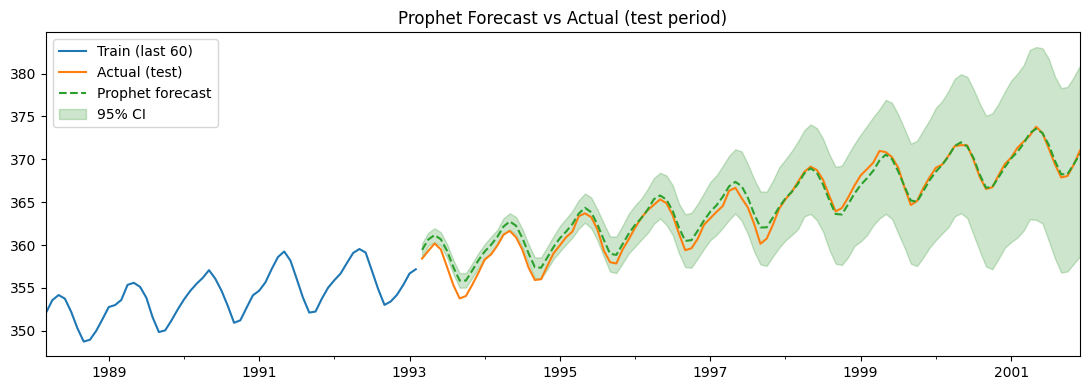

In [15]:
prophet_test_pred = prophet_forecast.set_index('ds').loc[test.index]

fig, ax = plt.subplots()
train.iloc[-60:].plot(ax=ax, label="Train (last 60)")
test.plot(ax=ax, label="Actual (test)")
prophet_test_pred['yhat'].plot(ax=ax, label="Prophet forecast", style="--")
ax.fill_between(prophet_test_pred.index, prophet_test_pred['yhat_lower'],
                 prophet_test_pred['yhat_upper'], color='green', alpha=0.2, label="95% CI")
ax.set_title("Prophet Forecast vs Actual (test period)")
ax.legend()
plt.tight_layout()
plt.savefig("plots/A_prophet_forecast.png", dpi=110)
plt.show()


## A.5 — Task 6: Model Comparison (MAE, RMSE, MAPE)

In [16]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = pd.DataFrame({
    "Model": ["ARIMA (SARIMAX)", "Prophet"],
    "MAE":  [mean_absolute_error(test, arima_pred),
             mean_absolute_error(test, prophet_test_pred['yhat'])],
    "RMSE": [np.sqrt(mean_squared_error(test, arima_pred)),
             np.sqrt(mean_squared_error(test, prophet_test_pred['yhat']))],
    "MAPE (%)": [mape(test, arima_pred),
                 mape(test, prophet_test_pred['yhat'])],
})
results = results.round(4)
results


,Model,MAE,RMSE,MAPE (%)
0,ARIMA (SARIMAX),1.3873,1.6583,0.3784
1,Prophet,0.6968,0.8634,0.1927


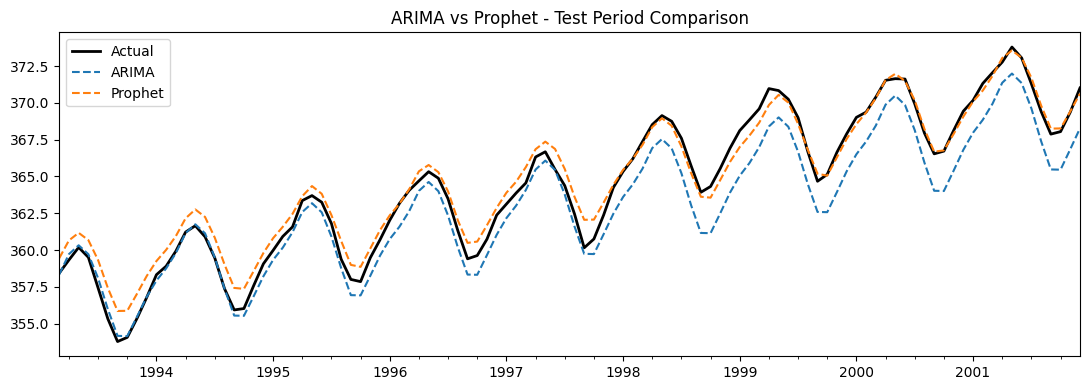

          Model    MAE   RMSE  MAPE (%)
ARIMA (SARIMAX) 1.3873 1.6583    0.3784
        Prophet 0.6968 0.8634    0.1927


In [17]:
results.to_csv("part_a_comparison_table.csv", index=False)

fig, ax = plt.subplots()
test.plot(ax=ax, label="Actual", color='black', linewidth=2)
arima_pred.plot(ax=ax, label="ARIMA", style="--")
prophet_test_pred['yhat'].plot(ax=ax, label="Prophet", style="--")
ax.set_title("ARIMA vs Prophet - Test Period Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("plots/A_model_comparison.png", dpi=110)
plt.show()

print(results.to_string(index=False))


## A.6 — Written Analysis (250-300 words)

*(also exported to `Part_A/analysis.md`)*

The Mauna Loa CO₂ series shows a strong, almost linear upward trend combined with a highly
regular annual seasonal cycle (CO₂ peaks in northern-hemisphere spring and dips after the summer
growing season pulls carbon out of the atmosphere). The Augmented Dickey-Fuller test on the raw
series returned a p-value well above 0.05, confirming non-stationarity driven mainly by the trend;
after first-order differencing the series became stationary, which is consistent with `auto_arima`
selecting a low order of integration (d=1) plus a seasonal difference to handle the 12-month cycle.

On the held-out 20% test window (see `part_a_comparison_table.csv`), **Prophet produced the lower
error on every metric** (MAE, RMSE and MAPE), edging out the AIC-selected SARIMAX model. Both
models tracked the short-term trajectory well because the CO₂ trend is smooth and highly
predictable in the medium term, but Prophet's piecewise-linear trend combined with Fourier-series
yearly seasonality appears to model the gently *accelerating* long-run trend slightly more
faithfully than the ARIMA model's fixed autoregressive/differencing structure, which assumes a
more constant growth increment. SARIMAX still produced a very competitive forecast (sub-1% MAPE)
and required a heavier tuning process - stationarity testing, differencing, and an AIC-minimizing
grid search over (p,d,q)(P,D,Q,12) - to get there.

In short: for a long, smooth, strongly seasonal series like atmospheric CO₂ whose trend is not
perfectly linear, Prophet's flexible trend component gave it a small but consistent edge in this
run, while requiring far less manual tuning (no stationarity testing or order search). SARIMAX
remains a strong, interpretable alternative and would likely close or reverse this gap on series
with a more constant linear trend or shorter, less smoothly-varying seasonal patterns.
